In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1: Exploratory Data Analysis (EDA)


In [71]:
# load dataset:
df = pd.read_csv("mushroom.csv")

In [72]:
# data explorations:
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [74]:
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


In [75]:
# Remove unnecessary index( Unnamed: 0 ) :
df = df.drop(columns = ['Unnamed: 0'])

In [76]:
df.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [77]:
# checking for missing values :
df.isnull().sum().sum()

np.int64(0)

In [78]:
# checking for duplicates:
df.duplicated().sum()

np.int64(1024)

In [79]:
# Remove duplicates :
df.drop_duplicates(inplace = True)

In [80]:
df.duplicated().sum()

np.int64(0)

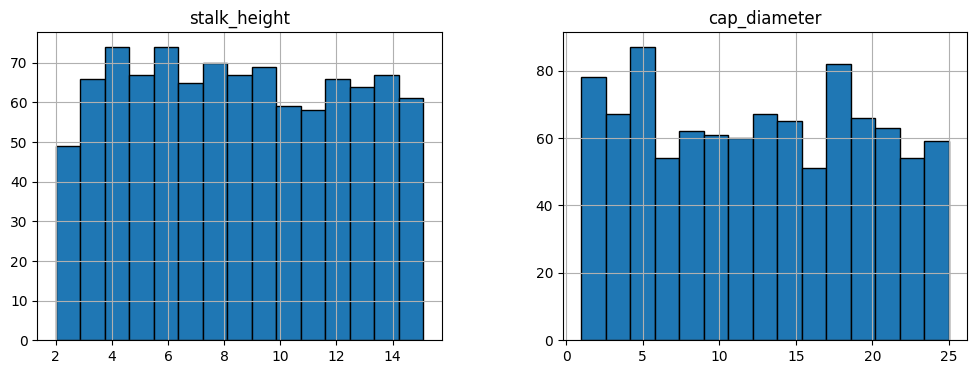

In [81]:
# visualize feature distribution :
    # Histogram 
df.hist( bins = 15 ,figsize = (12,4) , edgecolor = 'black')
plt.show()

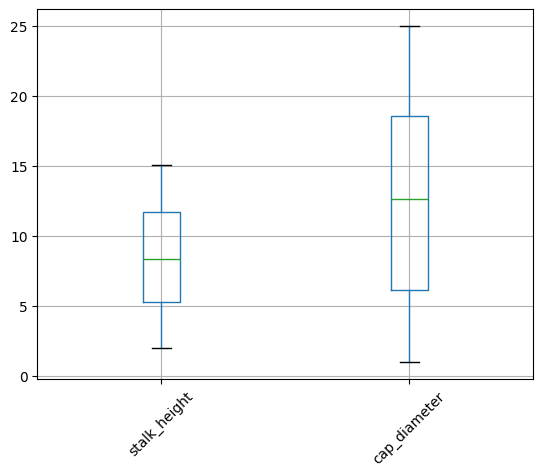

In [82]:
    # Box plot
df.boxplot()
plt.xticks(rotation = 45)
plt.show()


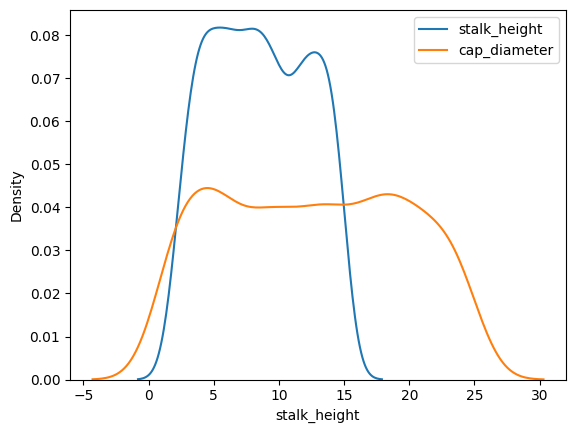

In [83]:
# density plots :
        # select numerical data:
for column in df.select_dtypes(include=['int64','float64']).columns:
    sns.kdeplot(df[column], label=column)
    
plt.legend()
plt.show()


In [84]:
    # convert cat to num:
df_encoded = pd.get_dummies(df, drop_first=True)

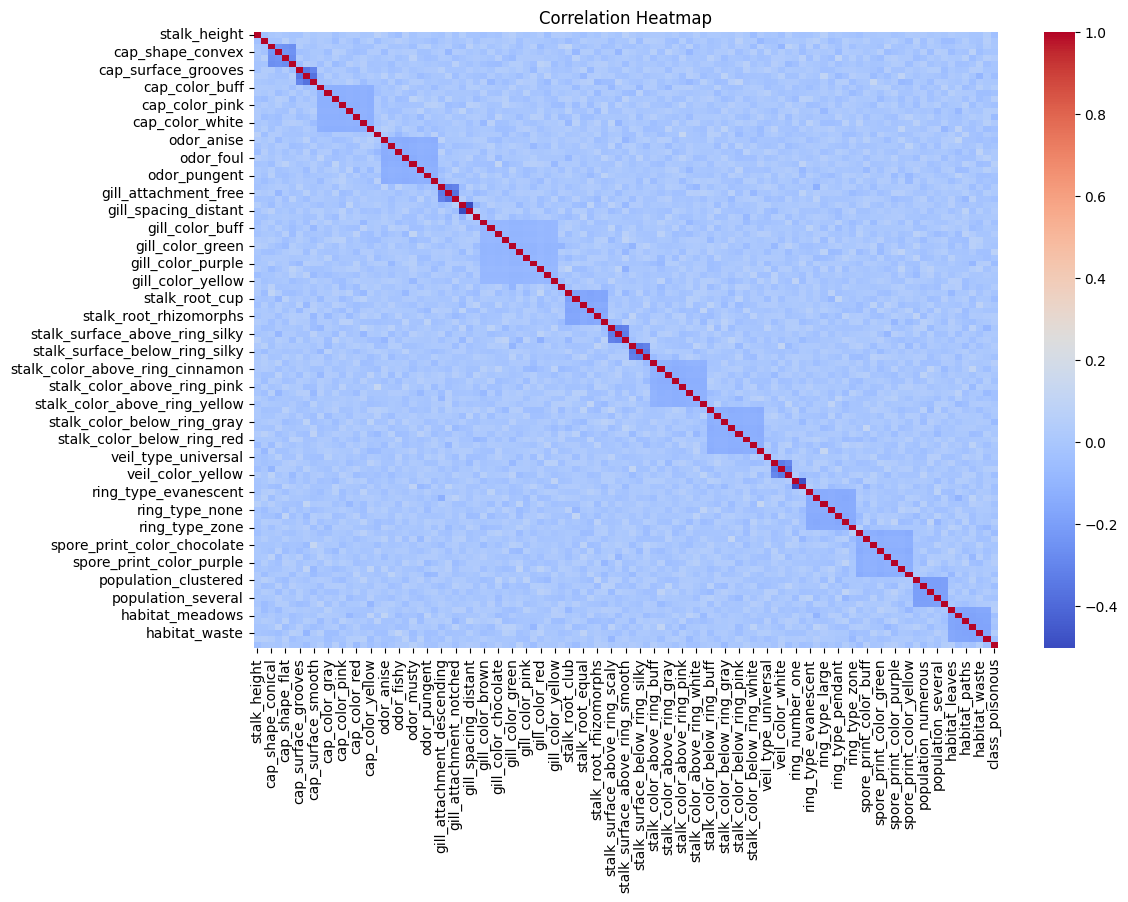

In [85]:
# Feature correlation -  relationship
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [87]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 1999
Columns: 105 entries, stalk_height to class_poisonous
dtypes: bool(103), float64(2)
memory usage: 121.0 KB


##  Data Preprocessing

In [92]:
# Encoding
from sklearn.preprocessing import LabelEncoder 

df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("Categorical features successfully encoded.")

Categorical features successfully encoded.


In [94]:
df_encoded.head()


,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,4,2,7,0,1,1,2,0,7,1,...,0,0,2,6,3,1,5,1,916,190
1,4,0,6,0,1,3,1,1,3,0,...,1,0,2,6,1,2,5,0,128,750
2,3,1,5,1,4,1,1,0,8,1,...,1,3,2,6,6,0,5,1,537,281
3,0,2,4,1,3,3,0,0,6,0,...,0,3,2,0,4,1,0,1,234,829
4,3,3,8,1,5,2,1,1,6,0,...,1,2,0,4,8,1,4,1,895,484


In [100]:
# split dataset to train and test:
from sklearn.model_selection import train_test_split
# define target :
x=df_encoded.drop('class',axis=1)
y=df_encoded['class']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [101]:
x_train.shape

(683, 24)

In [104]:
x_test.shape

(293, 24)

## Task 3: Data Visualization

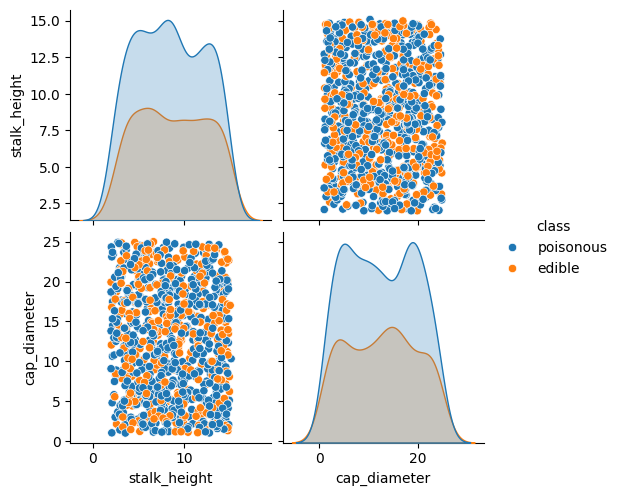

In [109]:
# pair plot:
sns.pairplot(data = df , hue='class',diag_kind='kde')
plt.show()

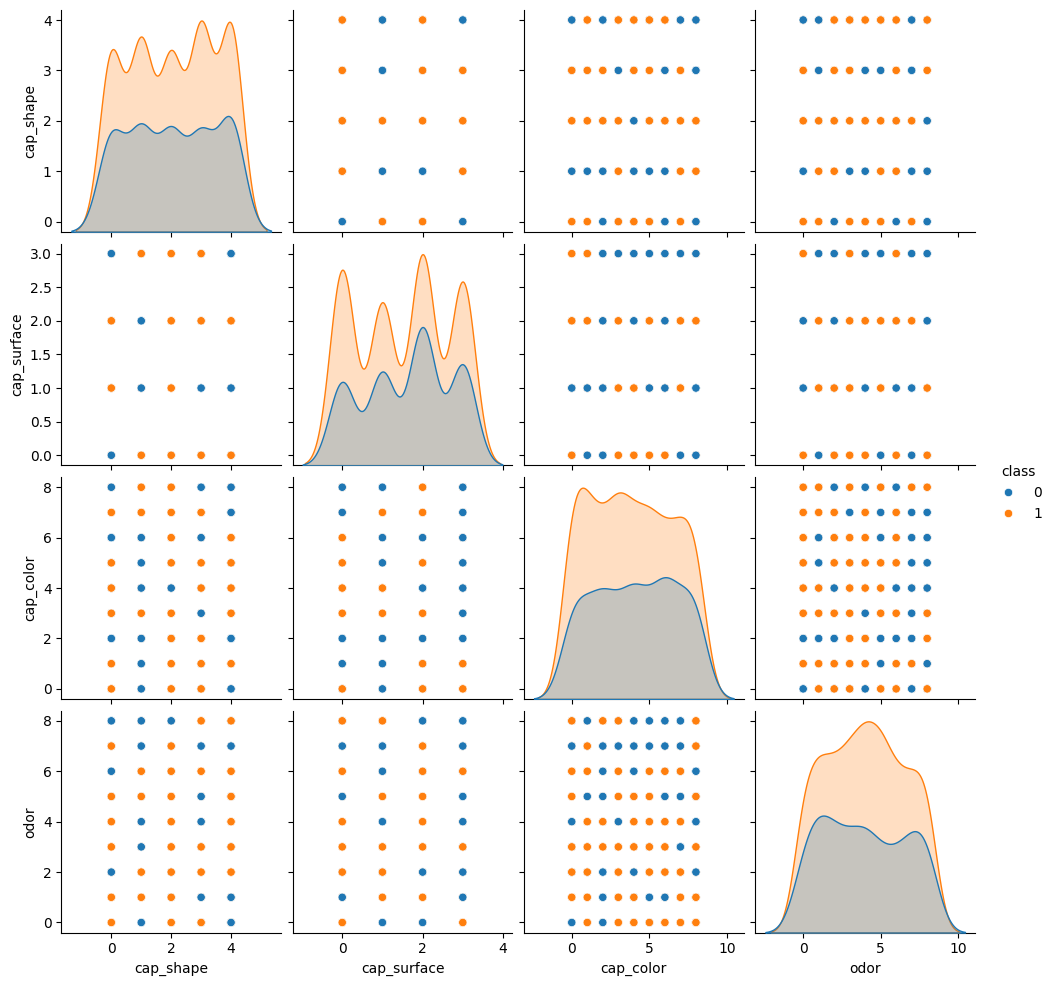

In [107]:
# Select a small subset of features for clearer visualization
subset_features = ['class', 'cap_shape', 'cap_surface', 'cap_color', 'odor']
sns.pairplot(df_encoded[subset_features], hue='class', diag_kind='kde')
plt.show()

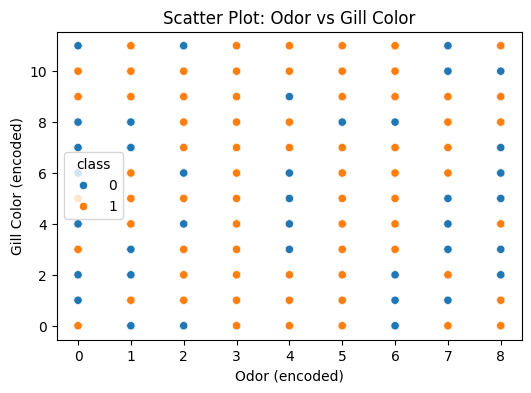

In [111]:
# scatter plot

plt.figure(figsize=(6,4))
sns.scatterplot(x=df_encoded['odor'], y=df_encoded['gill_color'], hue=df_encoded['class'])
plt.title("Scatter Plot: Odor vs Gill Color")
plt.xlabel("Odor (encoded)")
plt.ylabel("Gill Color (encoded)")
plt.show()


/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_64299/3784695151.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='Set2')


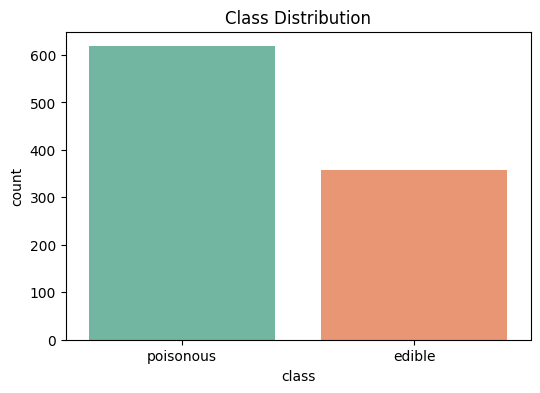

In [117]:
# countplot:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='Set2')
plt.title("Class Distribution")
plt.show()


## 4: SVM Implementation


In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Scale the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [123]:
# 1: Create the SVM Model (RBF Kernel works well for Mushroom dataset)
svm_model = SVC(kernel='rbf', random_state=42)

In [124]:
# 2: Train the Model using Training Data
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [126]:
# 3: Make Predictions on Test Data
y_pred = svm_model.predict(X_test_scaled)

In [128]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.01      0.02       106
           1       0.63      0.97      0.77       187

    accuracy                           0.62       293
   macro avg       0.40      0.49      0.39       293
weighted avg       0.47      0.62      0.50       293



In [130]:
# Step 4: Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Display Results
print("SVM Model Evaluation Results")
print("--------------------------------")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1-Score        : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

SVM Model Evaluation Results
--------------------------------
Accuracy        : 0.6246
Precision       : 0.4650
Recall          : 0.6246
F1-Score        : 0.4966

Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.01      0.02       106
           1       0.63      0.97      0.77       187

    accuracy                           0.62       293
   macro avg       0.40      0.49      0.39       293
weighted avg       0.47      0.62      0.50       293

Confusion Matrix:
 [[  1 105]
 [  5 182]]


##  5: Visualization of SVM Results

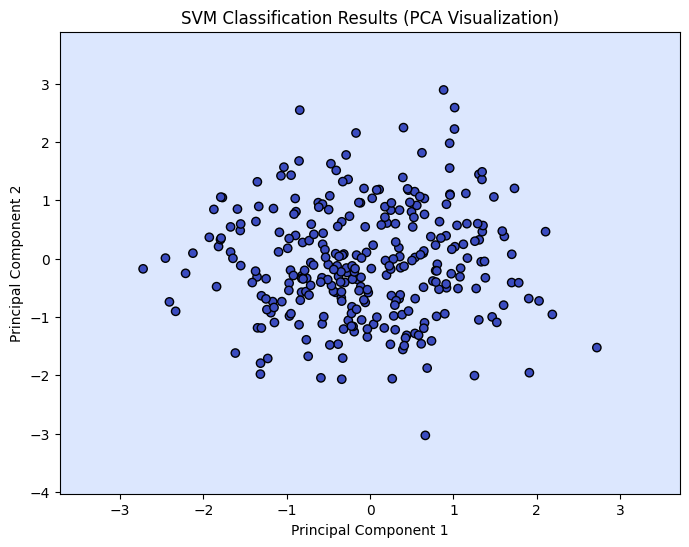

In [133]:
# Visualize classification results on the testing data.

from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Step 1: Reduce data to 2D using PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 2: Retrain SVM on the PCA-transformed data
svm_vis = SVC(kernel='rbf', random_state=42)
svm_vis.fit(X_train_pca, y_train)

# Step 3: Predict on the test set
y_pred_vis = svm_vis.predict(X_test_pca)

# Step 4: Create a meshgrid for the decision boundary
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Step 5: Predict class for each grid point
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 6: Plot decision boundary and points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_vis, edgecolor='k', cmap='coolwarm')
plt.title("SVM Classification Results (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


##  6: Parameter Tuning and Optimization

In [134]:
from sklearn.model_selection import GridSearchCV

# define model
svc = SVC()

In [144]:
# define parameters:
params = {
    'C' : [0.1,1,10],
    'kernel' : ['linear', 'rdf'],
    'gamma' : ['scale', 0.1]
}

In [145]:
# grid search with cross validation:
grid_search = GridSearchCV(svc, params, cv=5, scoring='accuracy', n_jobs=-1)

In [146]:
grid_search.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 666, in _validate_params
 

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.1],
                         'kernel': ['linear', 'rdf']},
             scoring='accuracy')

In [147]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)


In [148]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy: 0.6310433662516102


In [150]:
print("\nOptimized Model Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))


Optimized Model Performance:
Test Accuracy: 0.6382252559726962

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       106
           1       0.64      1.00      0.78       187

    accuracy                           0.64       293
   macro avg       0.32      0.50      0.39       293
weighted avg       0.41      0.64      0.50       293



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##  7: Comparison and Analysis

In [151]:
kernels = ['linear', 'poly', 'rbf']
results = {}


In [152]:
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[kernel] = acc
    print(f"Kernel: {kernel}")
    print(classification_report(y_test, y_pred))
    print("-"*40)

Kernel: linear
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       106
           1       0.64      1.00      0.78       187

    accuracy                           0.64       293
   macro avg       0.32      0.50      0.39       293
weighted avg       0.41      0.64      0.50       293

----------------------------------------
Kernel: poly
              precision    recall  f1-score   support

           0       0.27      0.06      0.09       106
           1       0.63      0.91      0.75       187

    accuracy                           0.60       293
   macro avg       0.45      0.49      0.42       293
weighted avg       0.50      0.60      0.51       293

----------------------------------------
Kernel: rbf
              precision    recall  f1-score   support

           0       0.17      0.01      0.02       106
           1       0.63      0.97      0.77       187

    accuracy                           0.62       293
   mac

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [153]:
print("Accuracy Comparison:")
for k, v in results.items():
    print(f"{k} Kernel Accuracy: {v:.4f}")

Accuracy Comparison:
linear Kernel Accuracy: 0.6382
poly Kernel Accuracy: 0.6041
rbf Kernel Accuracy: 0.6246


In [154]:
# Works well for high-dimensional and non-linear data.

# Effective in text classification, medical diagnosis, and image recognition.

# Requires hyperparameter tuning and proper preprocessing.

# May face scalability issues for very large datasets or highly imbalanced classes.